Import packages

In [24]:
import os
import matplotlib.pyplot as plt
import matplotlib as mpl 
import pandas as pd 
import numpy as np
import geopandas as gpd
import fiona
from shapely.geometry import Point
import contextily as ctx

### Import hydrometric stations

1. Navigate to the Canadian National Hydrometric Network dataset directory [(click here)](https://collaboration.cmc.ec.gc.ca/cmc/hydrometrics/www/HydrometricNetworkBasinPolygons/)
2. Identify the location of your home on MDA_Map.jpg (e.g., 08 Pacific)
3. Download the corresponding shapefile dataset under the shp folder (e.g., MDA_ADP_08.zip)
4. Save your downloaded dataset to this working directory

In [34]:
# read in the shapefile dataset using gpd
file =  os.path.join('C:\Python\School\hwrs564b_course_materials_kfmcculloch98\content_weekly\Week7_Geospatial\data', 'MDA_ADP_08_Station.shp')
gages = gpd.read_file(file)

# examine the attribute table 
print(type(gages))
print(gages.head())
print(gages.columns)
print(gages.shape) # number of entries

# check the projection
print(gages.crs)

# check the total spatial extent
print(gages.total_bounds)

<class 'geopandas.geodataframe.GeoDataFrame'>
  StationNum                              NameNom        Status        Etat  \
0    08AA001       AISHIHIK RIVER NEAR WHITEHORSE  discontinued      fermée   
1    08AA003   DEZADEASH RIVER AT HAINES JUNCTION        active  en service   
2    08AA004  KATHLEEN RIVER NEAR HAINES JUNCTION  discontinued      fermée   
3    08AA005        AISHIHIK LAKE NEAR WHITEHORSE        active  en service   
4    08AA007        SEKULMUN LAKE NEAR WHITEHORSE        active  en service   

  ProvTerr HYDAT_ver                    geometry  
0       YT   2021-01  POINT (-137.0611 60.86111)  
1       YT   2021-01  POINT (-137.5083 60.74806)  
2       YT   2021-01  POINT (-137.2292 60.59306)  
3       YT   2021-01  POINT (-136.9996 61.19744)  
4       YT   2021-01    POINT (-137.5905 61.536)  
Index(['StationNum', 'NameNom', 'Status', 'Etat', 'ProvTerr', 'HYDAT_ver',
       'geometry'],
      dtype='str')
(2180, 7)
EPSG:4326
[-138.0819    48.34667 -114.4756    61.

Filter the dataset

08NM


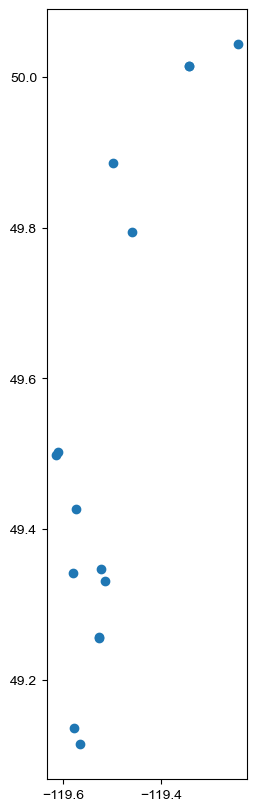

In [ ]:
# filter for stations where 'NameNom' contains 'Okanagan' (case-insensitive)
gages_okanagan = gages[gages['NameNom'].str.contains('Okanagan', case=False, na=False)]
gages_okanagan.shape

# extract the WSCSSDA from the filtered attribute table 
WSCSSDA = str(gages_okanagan.iloc[0]['StationNum'])[:4]
print(WSCSSDA)

#plot the subset
fig, ax = plt.subplots(figsize=(10, 10))
gages_okanagan.plot(ax=ax)
plt.show()

### Identify Water Service of Canada sub-sub-drainage area (WSCDAA)

In [27]:
# read in the index shapefile dataset using gpd
file =  os.path.join('C:\Python\School\hwrs564b_course_materials_kfmcculloch98\content_weekly\Week7_Geospatial\index', 'NHN_INDEX_22_INDEX_WORKUNIT_LIMIT_2.shp')
index = gpd.read_file(file)

# filter for the right WSCSSDA and extract stream dataset name
index_filtered=index[index['WSCSSDA']==WSCSSDA]
DATASETNAM = str(index_filtered.iloc[0]['DATASETNAM'])
print(DATASETNAM)

08NM000


### Import streams

1. Navigate to the Canadian National Hydrometric Network dataset directory [(click here)](https://ftp.maps.canada.ca/pub/nrcan_rncan/vector/geobase_nhn_rhn/shp_en//)
2. Navigate to the sub-folder based on the previously determined DATASETNAM
3. Download the corresponding shapefile dataset (e.g., nhn_rhn_08nm000_shp_en.zip)
4. Save your downloaded dataset to this working directory

c:\Users\kaden.mcculloch\AppData\Local\anaconda3\envs\hwrs564b\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


<class 'geopandas.geodataframe.GeoDataFrame'>
                                NID   VALDATE  ACQTECH DATASETNAM  ACCURACY  \
0  db34c7b69b7f481f8d21fba3cc76007b  20060422        5    08NM000        12   
1  2cb73d74556711d98a8f00055d8aa2de  19880101        5    08NM000        10   
2  ede19778555911d98a8f00055d8aa2de  19800101        5    08NM000        10   
3  859246c00a5d4ddfac174270a6f11dd2  20060422        5    08NM000        12   
4  3fe90dd2357440a2bc71078b2653fe6c  20060422        5    08NM000        12   

   PROVIDER  METACOVER  TYPE  DIRECTION  ISOLATED  ...  \
0         1          1     1          1         0  ...   
1         3         -1     1          1         0  ...   
2         3         -1     1          1         0  ...   
3         1          1     1          1         0  ...   
4         1          1     1          1         0  ...   

                         FROM_JUNCT                          TO_JUNCT  \
0  73de66a774ee48c0af4b3cbbdfc34ffb  a4bd66eb0ead47e1839d

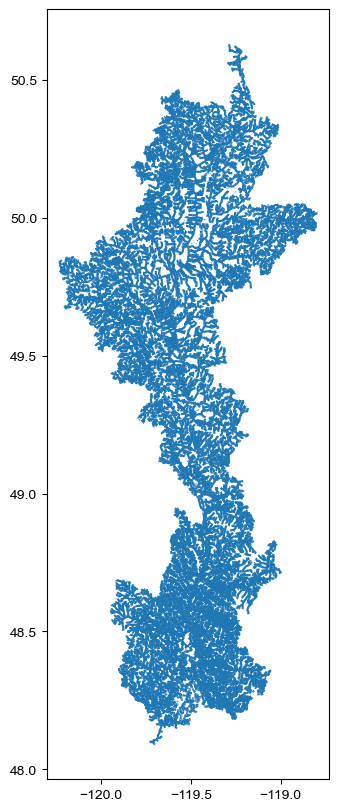

In [28]:
# read in the shapefile dataset using gpd
file =  os.path.join('C:\Python\School\hwrs564b_course_materials_kfmcculloch98\content_weekly\Week7_Geospatial\data', 'NHN_08NM000_1_0_HN_NLFLOW_1.shp')
streams = gpd.read_file(file)

# # examine the attribute table 
print(type(streams))
print(streams.head())
print(streams.columns)
print(streams.shape) # number of entries

# check the projection
print(streams.crs)

# plot the streams
fig, ax = plt.subplots(figsize=(10, 10))
streams.plot(ax=ax)
plt.show()

### Import watershed boundaries

In [29]:
# read in the shapefile dataset using gpd
file =  os.path.join('C:\Python\School\hwrs564b_course_materials_kfmcculloch98\content_weekly\Week7_Geospatial\data', 'MDA_ADP_08_DrainageBasin_BassinDeDrainage.shp')
watersheds = gpd.read_file(file)

# examine the attribute table 
print(type(watersheds))
print(watersheds.head())
print(watersheds.columns)
print(watersheds.shape) # number of entries

# check the projection
print(watersheds.crs)

# check the total spatial extent
print(watersheds.total_bounds)

<class 'geopandas.geodataframe.GeoDataFrame'>
  StationNum                              NameNom        Status        Etat  \
0    08AA001       AISHIHIK RIVER NEAR WHITEHORSE  discontinued      fermée   
1    08AA003   DEZADEASH RIVER AT HAINES JUNCTION        active  en service   
2    08AA004  KATHLEEN RIVER NEAR HAINES JUNCTION  discontinued      fermée   
3    08AA005        AISHIHIK LAKE NEAR WHITEHORSE        active  en service   
4    08AA007        SEKULMUN LAKE NEAR WHITEHORSE        active  en service   

   Area_km2  Aire_km2 Remark Remarque                Version   Date_rev  \
0  4375.150  4375.150   None     None  June 2024 / juin 2024 2024-06-01   
1  8409.860  8409.860   None     None  June 2024 / juin 2024 2024-06-01   
2   695.285   695.285   None     None  June 2024 / juin 2024 2024-06-01   
3  2756.490  2756.490   None     None  June 2024 / juin 2024 2024-06-01   
4  1221.530  1221.530   None     None  June 2024 / juin 2024 2024-06-01   

   Shape_Leng    Shape_Area 

Filter the dataset

(15, 13)


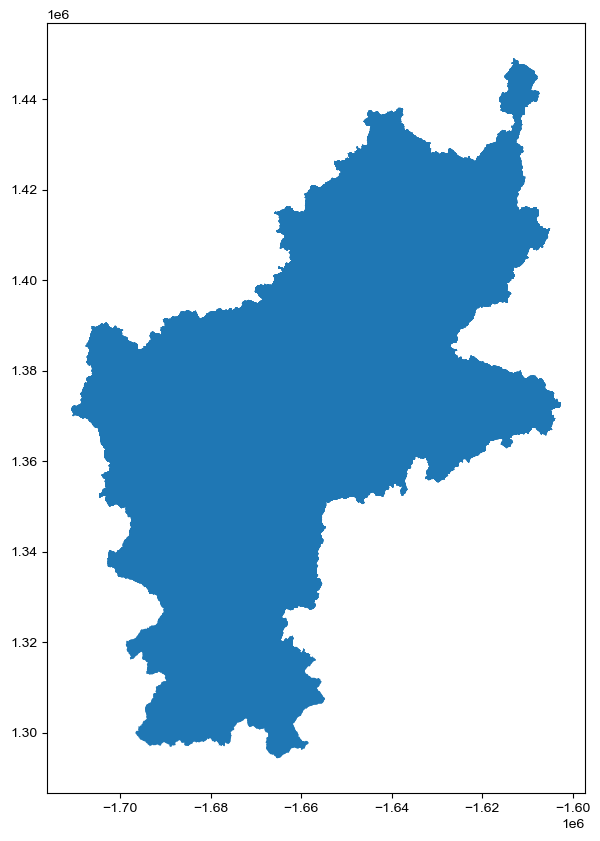

In [30]:
# filter for watersheds where 'NameNom' contains 'Okanagan' (case-insensitive)
watersheds_okanagan = watersheds[watersheds['NameNom'].str.contains('Okanagan', case=False, na=False)]
print(watersheds_okanagan.shape)

# plot the subset of watersheds
fig, ax = plt.subplots(figsize=(10, 10))
watersheds_okanagan.plot(ax=ax)
plt.show()

### Pre-processing for plotting

In [31]:
# verify the CRS of different datasets
print("Hydrometric Stations CRS:")
print(gages_okanagan.crs)
print("Streams CRS:")
print(streams.crs)
print("\nWatershed Boundaries CRS:")
print(watersheds_okanagan.crs)

# reproject our watersheds to match the hydrometric stations CRS
watersheds_okanagan_reprj = watersheds_okanagan.to_crs(gages_okanagan.crs)
# NOTE: .to_crs() will only work if your original spatial object has a CRS assigned 
# to it AND if that CRS is the correct CRS!

# reproject our streams to match the hydrometric stations CRS
streams_reprj = streams.to_crs(gages_okanagan.crs)
# NOTE: .to_crs() will only work if your original spatial object has a CRS assigned 
# to it AND if that CRS is the correct CRS!

# verify reprojections

print("\nRe-projected Watershed Boundaries CRS:")
print(watersheds_okanagan_reprj.crs)

print("\nRe-projected Streams CRS:")
print(streams_reprj.crs)

Hydrometric Stations CRS:
EPSG:4326
Streams CRS:
EPSG:4617

Watershed Boundaries CRS:
PROJCS["Canada_Albers_Equal_Area_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",40],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",50],PARAMETER["standard_parallel_2",70],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","102001"]]

Re-projected Watershed Boundaries CRS:
EPSG:4326

Re-projected Streams CRS:
EPSG:4326


### Generate map (without AI help)

[-120.23661354   49.1017739  -118.79719557   50.63473942]


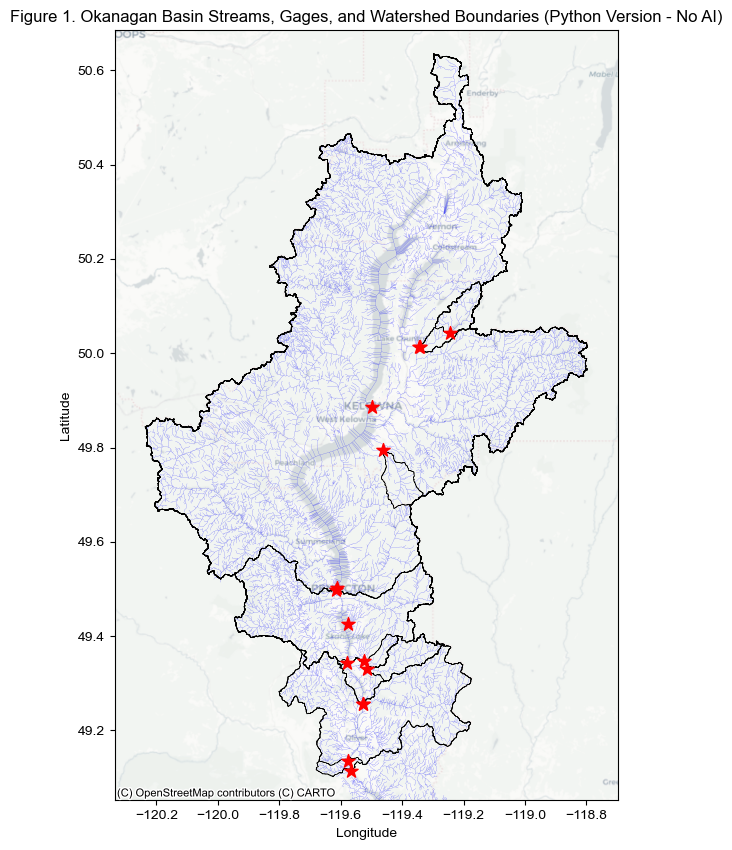

In [35]:
# check the total spatial extent of re-projected filtered watersheds
print(watersheds_okanagan_reprj.total_bounds)

fig, ax = plt.subplots(figsize=(10, 10))

# plot watersheds
watersheds_okanagan_reprj.boundary.plot(ax=ax, color=None, edgecolor='black', linewidth=0.5, zorder=2)

# plot hydrometric stations
gages_okanagan.plot(ax=ax, color='red', marker='*', markersize=100, zorder=3)

# plot streams
streams_reprj.plot(ax=ax, color='blue', linewidth=0.1, zorder=1)

# add basemap with matching CRS
ctx.add_basemap(ax, crs=gages.crs, source=ctx.providers.CartoDB.Positron, alpha=0.95, zorder=0)

ax.set_title("Figure 1. Okanagan Basin Streams, Gages, and Watershed Boundaries (Python Version - No AI)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.xlim(watersheds_okanagan_reprj.total_bounds[0]-0.1,watersheds_okanagan_reprj.total_bounds[2]+0.1)
plt.ylim(watersheds_okanagan_reprj.total_bounds[1]-0.05,watersheds_okanagan_reprj.total_bounds[3]+0.05)

plt.savefig("Figure 1.pdf", format="pdf", bbox_inches="tight", dpi=300)

plt.show()


### Generate map (with AI help)

Axis limits (projected): (np.float64(-13387883.299779363), np.float64(-13221238.61322176)) (np.float64(6286852.212449371), np.float64(6562231.676141548))
Using basemap zoom: 12


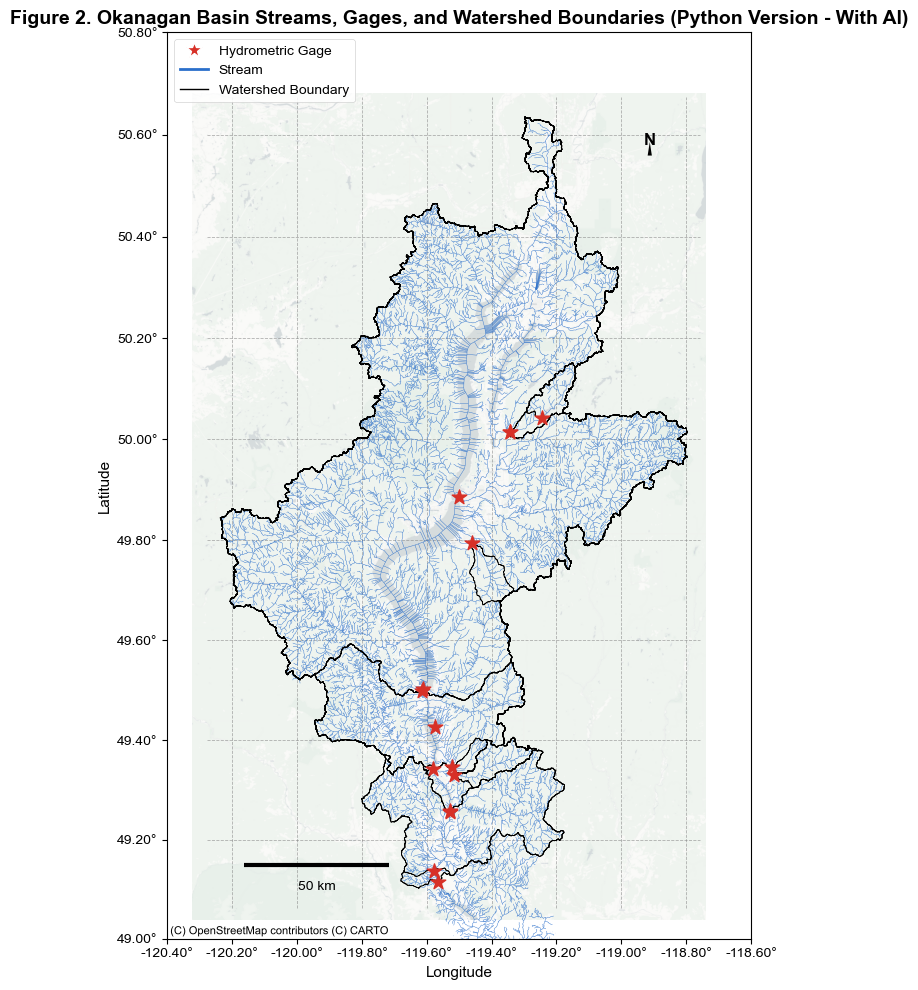

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.lines import Line2D
from matplotlib import rcParams
from pyproj import Transformer
import geopandas as gpd

# Ensure Arial font
rcParams['font.family'] = 'Arial'

# Target CRS for basemap
target_crs = "EPSG:3857"

# --- Reproject inputs to Web Mercator (required by contextily) ---
watersheds_m = watersheds_okanagan_reprj.to_crs(target_crs)
gages_m = gages_okanagan.to_crs(target_crs)
streams_m = streams_reprj.to_crs(target_crs)

# Projected bounds
xmin_m, ymin_m, xmax_m, ymax_m = watersheds_m.total_bounds

# Compute geographic bounds (lon/lat) for graticule/ticks
transformer_to4326 = Transformer.from_crs(target_crs, "EPSG:4326", always_xy=True)
min_lon, min_lat = transformer_to4326.transform(xmin_m, ymin_m)
max_lon, max_lat = transformer_to4326.transform(xmax_m, ymax_m)

# Helper to pick "nice" lon/lat intervals
def nice_interval(span_deg):
    bases = [0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]
    for b in bases:
        if span_deg / b <= 8:
            return b
    return 10

lon_span = max_lon - min_lon
lat_span = max_lat - min_lat
lon_step = nice_interval(lon_span)
lat_step = nice_interval(lat_span)

lon_lines = np.arange(np.floor(min_lon / lon_step) * lon_step,
                      np.ceil(max_lon / lon_step) * lon_step + 1e-9, lon_step)
lat_lines = np.arange(np.floor(min_lat / lat_step) * lat_step,
                      np.ceil(max_lat / lat_step) * lat_step + 1e-9, lat_step)

# Transformer to project lon/lat -> Web Mercator for plotting grid & tick positions
transformer_to3857 = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot vector layers first (they are drawn; basemap must be added AFTER axis limits)
streams_m.plot(ax=ax, color='#2a6fcb', linewidth=0.3, zorder=1)
watersheds_m.boundary.plot(ax=ax, color='black', linewidth=0.6, zorder=2)
gages_m.plot(ax=ax, color='#d73027', marker='*', markersize=120, zorder=3)

# Title and axis labels
ax.set_title("Figure 2. Okanagan Basin Streams, Gages, and Watershed Boundaries (Python Version - With AI)", fontsize=14, weight='bold')
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude", fontsize=11)

# --- Set axis limits BEFORE adding basemap (contextily uses current extent) ---
xbuf = (xmax_m - xmin_m) * 0.02
ybuf = (ymax_m - ymin_m) * 0.02
ax.set_xlim(xmin_m - xbuf, xmax_m + xbuf)
ax.set_ylim(ymin_m - ybuf, ymax_m + ybuf)

# Debug: print axis limits
print("Axis limits (projected):", ax.get_xlim(), ax.get_ylim())

# --- Compute a reasonable zoom and clamp to provider limits (0-20) ---
try:
    inferred_zoom = ctx.tile._calculate_zoom((xmin_m, ymin_m, xmax_m, ymax_m), width_px=fig.bbox.width)
    zoom = int(round(inferred_zoom))
except Exception:
    zoom = 12  # fallback
zoom = max(0, min(zoom, 20))
print("Using basemap zoom:", zoom)

ctx.add_basemap(ax, crs=target_crs, source=ctx.providers.CartoDB.Positron, zoom=zoom, alpha=0.95, zorder=0)

# --- Graticule: plot meridians/parallels transformed to Web Mercator ---
for lon in lon_lines:
    lat_vals = np.linspace(min_lat - lat_step * 0.2, max_lat + lat_step * 0.2, 300)
    lon_vals = np.full_like(lat_vals, lon)
    xs, ys = transformer_to3857.transform(lon_vals, lat_vals)
    ax.plot(xs, ys, color='gray', linewidth=0.6, linestyle='--', alpha=0.6, zorder=0.2)

for lat in lat_lines:
    lon_vals = np.linspace(min_lon - lon_step * 0.2, max_lon + lon_step * 0.2, 300)
    lat_vals = np.full_like(lon_vals, lat)
    xs, ys = transformer_to3857.transform(lon_vals, lat_vals)
    ax.plot(xs, ys, color='gray', linewidth=0.6, linestyle='--', alpha=0.6, zorder=0.2)

# Tick positions in projected coordinates, but labels in degrees
bottom_lons = lon_lines
bottom_xs, bottom_ys = transformer_to3857.transform(bottom_lons, np.full_like(bottom_lons, min_lat))
ax.set_xticks(bottom_xs)
ax.set_xticklabels([f"{lon:.2f}°" if abs(lon) >= 1 else f"{lon:.3f}°" for lon in bottom_lons], fontsize=10)

left_lats = lat_lines
left_xs, left_ys = transformer_to3857.transform(np.full_like(left_lats, min_lon), left_lats)
ax.set_yticks(left_ys)
ax.set_yticklabels([f"{lat:.2f}°" if abs(lat) >= 1 else f"{lat:.3f}°" for lat in left_lats], fontsize=10)

# Minimal legend
legend_elements = [
    Line2D([0], [0], marker='*', color='w', label='Hydrometric Gage',
           markerfacecolor='#d73027', markeredgecolor='white', markersize=12),
    Line2D([0], [0], color='#2a6fcb', lw=2, label='Stream'),
    Line2D([0], [0], color='black', lw=1, label='Watershed Boundary'),
]
leg = ax.legend(handles=legend_elements, loc='upper left', frameon=True,
                framealpha=0.85, fontsize=10)
leg.get_frame().set_linewidth(0.5)

# Robust scale bar (projected meters)
map_width_m = (xmax_m - xmin_m)
raw = map_width_m / 8.0
if raw <= 0 or not np.isfinite(raw):
    scalelen = 5000
else:
    pow10 = 10 ** np.floor(np.log10(raw))
    for base in [1, 2, 5, 10]:
        if base * pow10 >= raw:
            scalelen = int(base * pow10)
            break
    else:
        scalelen = int(10 * pow10)

sb_x = xmin_m + (xmax_m - xmin_m) * 0.05
sb_y = ymin_m + (ymax_m - ymin_m) * 0.03
ax.plot([sb_x, sb_x + scalelen], [sb_y, sb_y], color='black', linewidth=3, solid_capstyle='butt', zorder=5)
label = f"{scalelen//1000} km" if scalelen >= 1000 else f"{scalelen} m"
ax.text(sb_x + scalelen / 2, sb_y - (ymax_m - ymin_m) * 0.02, label,
        ha='center', va='top', fontsize=10, zorder=5, color='black')

# North arrow
x_arrow = xmin_m + (xmax_m - xmin_m) * 0.92
y_arrow = ymin_m + (ymax_m - ymin_m) * 0.90
arrow_length = (ymax_m - ymin_m) * 0.05
ax.arrow(x_arrow, y_arrow, 0, arrow_length, head_width=(xmax_m-xmin_m)*0.009,
         head_length=arrow_length*0.35, fc='black', ec='black', linewidth=0, zorder=6)
ax.text(x_arrow, y_arrow + arrow_length + (ymax_m - ymin_m) * 0.01, 'N',
        ha='center', va='bottom', fontsize=12, weight='bold', zorder=6, color='black')

plt.tight_layout()

plt.savefig("Figure 2.pdf", format="pdf", bbox_inches="tight", dpi=300)

plt.show()
